In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#1.  Load data
df = pd.read_csv('../data/raw/sleep_mobile_stress_dataset_15000.csv')

#2. Basic Shape
print(f'Rows: {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print('\n')


#3. Column name & data types
print(df.dtypes)
print('\n')

Rows: 15000
Columns: 13


user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object




In [80]:
#4. Check for missing values
missing = df.isnull().sum()
print(missing)


user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64


In [81]:
#5. Target column distribution - VERY IMPORTANT
print(df['stress_level'].value_counts())
print('\n')
print(df['stress_level'].value_counts(normalize=True) * 100)

stress_level
10.00    3875
1.00      250
5.98       28
9.76       27
5.32       26
         ... 
1.60        2
1.37        2
1.64        1
1.05        1
1.03        1
Name: count, Length: 900, dtype: int64


stress_level
10.00    25.833333
1.00      1.666667
5.98      0.186667
9.76      0.180000
5.32      0.173333
           ...    
1.60      0.013333
1.37      0.013333
1.64      0.006667
1.05      0.006667
1.03      0.006667
Name: proportion, Length: 900, dtype: float64


In [82]:
df.describe().round(2)

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,7500.50,38.49,5.50,59.71,6.51,6.25,6.98,2.00,59.16,160.89,6.87
std,4330.27,12.01,2.60,34.64,1.45,1.71,2.75,1.41,34.53,80.86,2.73
min,1.00,18.00,1.00,0.00,4.00,1.00,1.00,0.00,0.00,20.00,1.00
25%,3750.75,28.00,3.26,29.00,5.26,5.00,4.75,1.00,29.00,92.00,4.70
50%,7500.50,38.00,5.49,60.00,6.49,6.25,7.38,2.00,59.00,162.00,7.38
75%,11250.25,49.00,7.76,90.00,7.79,7.50,10.00,3.00,89.00,231.00,9.45
max,15000.00,59.00,10.00,119.00,9.00,10.00,10.00,4.00,119.00,299.00,10.00


In [83]:
df.columns.tolist()

['user_id',
 'age',
 'gender',
 'occupation',
 'daily_screen_time_hours',
 'phone_usage_before_sleep_minutes',
 'sleep_duration_hours',
 'sleep_quality_score',
 'stress_level',
 'caffeine_intake_cups',
 'physical_activity_minutes',
 'notifications_received_per_day',
 'mental_fatigue_score']

In [84]:
#6. Check Stress level distribution
print("Stress level range:", df['stress_level'].min() ,'-', df['stress_level'].max())

Stress level range: 1.0 - 10.0


In [85]:
print("Unique values:", df['stress_level'].nunique())

Unique values: 900


In [22]:
#7. Bin continuous stress into 3 classes
bins = [0, 4, 7, 10]
labels = ['Low', 'Medium', 'High']

df['stress_class'] = pd.cut(df['stress_level'], bins=bins, labels=labels, include_lowest=True)

In [ ]:
#8. Verify class distribution
print(df['stress_class'].value_counts())
print('\n')
print(df['stress_class'].value_counts(normalize=True) * 100)

stress_class
High      8077
Medium    4189
Low       2734
Name: count, dtype: int64


stress_class
High      53.846667
Medium    27.926667
Low       18.226667
Name: proportion, dtype: float64


[2734 4189 8077]


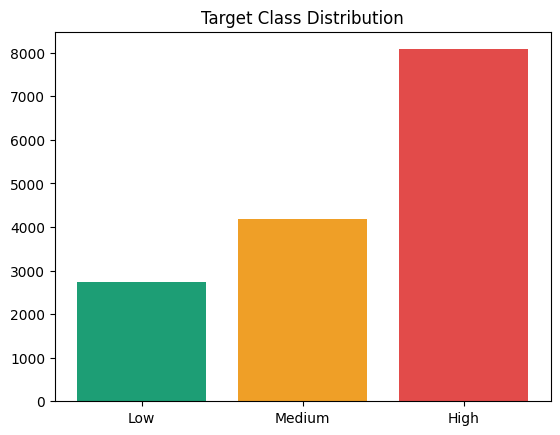

In [23]:
order = ['Low', 'Medium', 'High']

counts = df['stress_class'].value_counts().reindex(order)

print(counts.values)

plt.bar(order, counts.values, color=['#1D9E75', '#EF9F27', '#E24B4A'])
plt.title('Target Class Distribution')

plt.show()

C:\Users\balaj\AppData\Local\Temp\ipykernel_27428\562988438.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stress_class', y=feat, order=order,
C:\Users\balaj\AppData\Local\Temp\ipykernel_27428\562988438.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stress_class', y=feat, order=order,
C:\Users\balaj\AppData\Local\Temp\ipykernel_27428\562988438.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='stress_class', y=feat, order=order,
C:\Users\balaj\AppData\Local\Temp\ipykernel_27428\562988438.py:2

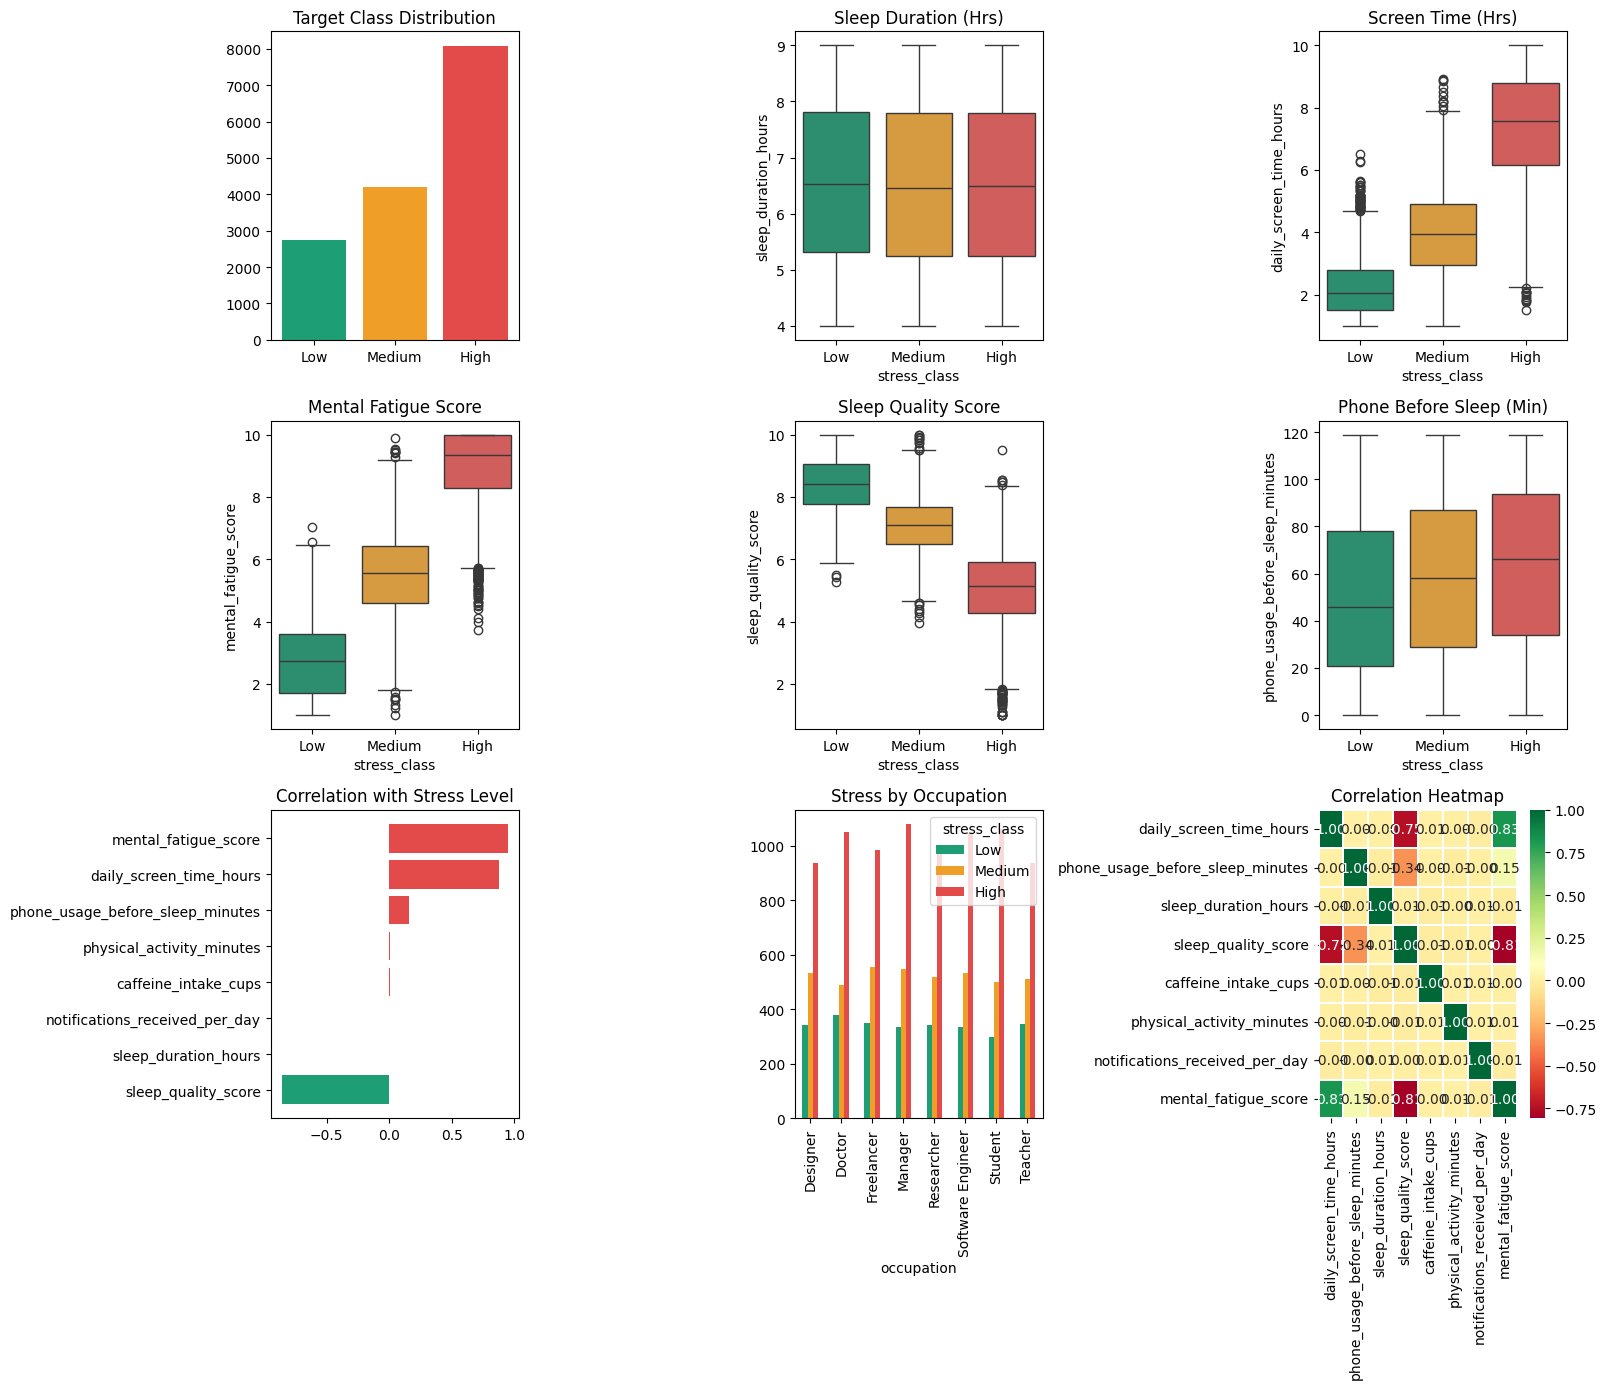

In [ ]:
# PHASE - 2 - EDA

palette = {'Low': '#1D9E75', 'Medium': '#EF9F27', "High": '#E24B4A'}
order = ['Low', 'Medium', 'High']
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

# 2a. Target class distribution
counts = df['stress_class'].value_counts().reindex(order)

axes[0, 0].bar(order, counts.values, color=['#1D9E75', '#EF9F27', '#E24B4A'])
axes[0, 0].set_title('Target Class Distribution')


# 2b. Feature vs Stress class box plots

features = [
    ('sleep_duration_hours',    'Sleep Duration (Hrs)'),
    ('daily_screen_time_hours',   'Screen Time (Hrs)'),
    ('mental_fatigue_score',        'Mental Fatigue Score'),
    ('sleep_quality_score',          'Sleep Quality Score'),
    ('phone_usage_before_sleep_minutes',  'Phone Before Sleep (Min)')
]
# positions = [(1,0),(0,1),(1,2),(0,2),(1,1)]
positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
for (feat, label), (row, col) in zip(features, positions):
    sns.boxplot(data=df, x='stress_class', y=feat, order=order,
                palette=palette, ax=axes[row, col])
    axes[row, col].set_title(label)

# 2c. Correlation Bar chart

num_cols = ['daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
            'sleep_duration_hours', 'sleep_quality_score',
            'caffeine_intake_cups', 'physical_activity_minutes',
            'notifications_received_per_day', 'mental_fatigue_score']
corrs = df[num_cols+['stress_level']].corr()['stress_level']\
    .drop('stress_level').sort_values()

colors = ['#E24B4A' if v > 0 else '#1D9E75' for v in corrs.values]
axes[2, 0].barh(corrs.index, corrs.values, color=colors)
axes[2, 0].set_title('Correlation with Stress Level')

# 2d. Occupation vs stress stacked bar
occ = df.groupby(['occupation', 'stress_class']) \
    .size().unstack(fill_value=0)
occ[order].plot(kind='bar', ax=axes[2, 1], color=[
                '#1D9E75', '#EF9F27', '#E24B4A'])
axes[2, 1].set_title('Stress by Occupation')

# 2e. Correlation heatmap

sns.heatmap(df[num_cols].corr(), ax=axes[2, 2], cmap='RdYlGn',
            annot=True, fmt='.2f', linewidth=0.3)
axes[2, 2].set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('EDA plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [94]:
## PHASE - 3 - DATA PREPROCESSING

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

df_model = df.drop(columns=['user_id', 'stress_level']).copy()

#3a. Encode categorical features
le_gender = LabelEncoder()
le_occupation = LabelEncoder()

df_model['gender'] = le_gender.fit_transform(df_model['gender'])
df_model['occupation'] = le_occupation.fit_transform(df_model['occupation'])

#3b. Feature Engineering
df_model['screen_to_sleep_ratio'] = (df_model['daily_screen_time_hours'] / (df_model['sleep_duration_hours'] +0.1))

df_model['pre_sleep_screen_burden'] = (df_model['phone_usage_before_sleep_minutes'] * (df_model['daily_screen_time_hours']))

df_model['fatigue_sleep_interaction'] = (df_model['mental_fatigue_score'] * (10 - df_model['sleep_quality_score']))

df_model['activity_caffeine_ratio'] = (df_model['physical_activity_minutes'] / (df_model['caffeine_intake_cups'] + 1))


#3c. Encode target

le_target = LabelEncoder()
df_model['stress_class'] = le_target.fit_transform(df_model['stress_class'])

X = df_model.drop(columns=['stress_class'])
y = df_model['stress_class']

#3d. Stratified 70/15/15 split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

#3d. Scale Features

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

Train: 10500 | Val: 2250 | Test: 2250


In [95]:
## PHASE - 4 - MODEL BUILDING

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

models = {"Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
          "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
          'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42)}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}


for name, model in models.items():
    model.fit(X_train_sc, y_train)
    val_acc = model.score(X_val_sc, y_val)
    cv_f1 = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='f1_weighted')

    results[name] ={'Val_acc': val_acc,
                    'cv_f1': cv_f1.mean(),
                    'cv_std': cv_f1.std()}
    
    print(f'{name}: Val={val_acc:.4f} | CV F1 = {cv_f1.mean():.4f}')

best_name = max(results, key=lambda k: results[k]['cv_f1'])
best_model = models[best_name]
print('Best_model:', best_name)


Logistic Regression: Val=0.9022 | CV F1 = 0.8971
Random Forest: Val=0.8956 | CV F1 = 0.8979
Gradient Boosting: Val=0.8929 | CV F1 = 0.8962
Best_model: Random Forest


              precision    recall  f1-score   support

        High       0.95      0.95      0.95      1212
         Low       0.85      0.84      0.84       410
      Medium       0.80      0.80      0.80       628

    accuracy                           0.89      2250
   macro avg       0.86      0.86      0.86      2250
weighted avg       0.89      0.89      0.89      2250

Weighted AUC-ROC: 0.9778


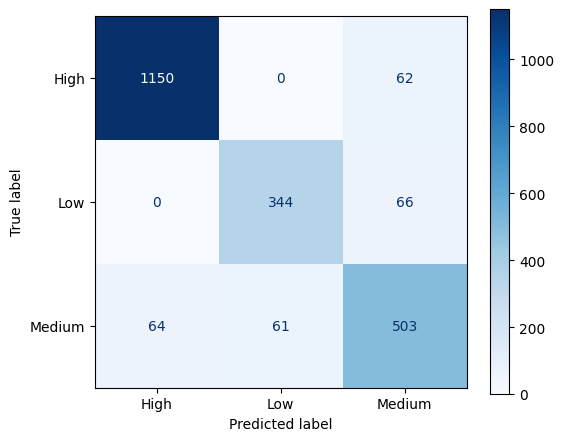

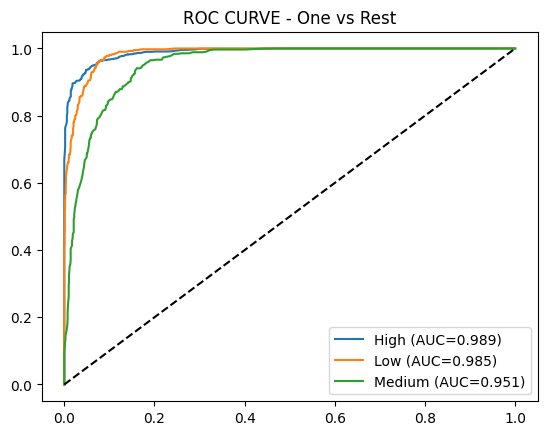

In [100]:
## PHASE - 5 - EVALUATION METRIX

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc

from sklearn.preprocessing import label_binarize

y_pred = best_model.predict(X_test_sc)
y_proba = best_model.predict_proba(X_test_sc)

#5a. Full classification report
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

#5b. Weighted AUC-ROC (multicalss one-vs-rest)
roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print(f'Weighted AUC-ROC: {roc:.4f}')

#5c. Confusion Matrix plots
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le_target.classes_, cmap='Blues', ax=ax)
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

#5d. Pre-class ROC curves
y_test_bin = label_binarize(y_test, classes=[0,1,2])
for i, cls in enumerate(le_target.classes_):
    fpr, tpr, _ =roc_curve(y_test_bin[:,i], y_proba[:, i])
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC={auc_val:.3f})')
plt.plot([0,1], [0,1], "k--")
plt.title("ROC CURVE - One vs Rest")
plt.legend()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

In [102]:
## PHASE - 6 - HYPER PARAMETER TUNING

from sklearn.model_selection import RandomizedSearchCV

param_grid = {'n_estimators': [100,200,300],
              'max_depth': [None, 10,20,30],
              'min_samples_split': [2,5,10],
              'min_samples_leaf': [1,2,4],
              "max_features": ['sqrt', 'log2']}

search = RandomizedSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid, n_iter=20,
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring='f1_weighted', random_state=42, n_jobs=-1,verbose=1)
search.fit(X_train_sc, y_train)

print("Best params: ", search.best_params_)
print("Best CV F1:", round(search.best_score_, 4))

tuned_model = search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test_sc)

print(classification_report(y_test, y_pred_tuned, target_names=le_target.classes_))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params:  {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}
Best CV F1: 0.8994
              precision    recall  f1-score   support

        High       0.95      0.95      0.95      1212
         Low       0.85      0.85      0.85       410
      Medium       0.80      0.80      0.80       628

    accuracy                           0.89      2250
   macro avg       0.87      0.87      0.87      2250
weighted avg       0.89      0.89      0.89      2250



In [ ]:
import joblib

# Save all artifacts
joblib.dump(tuned_model, 'stress_classifier.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_target, 'le_target.pkl')
joblib.dump(le_gender, 'le_gender.pkl')
joblib.dump(le_occupation, 'le_occupation.pkl')

print('Saved: stress_classifier.pkl')
print('Saved: scaler.pkl')
print('Saved: le_target.pkl')
print('Saved: le_gender.pkl')
print('Saved: le_occupation.pkl')

# Loading them back later
model = joblib.load('stress_classifier.pkl')
scaler = joblib.load('scaler.pkl')
le_target = joblib.load('le_target.pkl')
le_gender = joblib.load('le_gender.pkl')
le_occupation = joblib.load('le_occupation.pkl')



Saved: stress_classifier.pkl
Saved: scaler.pkl
Saved: le_target.pkl
Saved: le_gender.pkl
Saved: le_occupation.pkl
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
